# **Bank Churn Dataset Bianry Classification**

**According to the provided dataset we would find who would choose the bank or leave...**

### **Data Description**
* customer_id, unused variable.
* credit_score, used as input.
* country, used as input.
* gender, used as input.
* age, used as input.
* tenure, used as input.
* balance, used as input.
* products_number, used as input.
* credit_card, used as input.
* active_member, used as input.
* estimated_salary, used as input.
* churn, used as the target. 1 if the client has left the bank during some period or 0 if he/she has not. Aim is to Predict the Customer Churn for ABC Bank.

### Import

In [1]:
## Import Libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout 


In [2]:
df_train = pd.read_csv('data/Bank Churn Data/train.csv')
df_test = pd.read_csv('data/Bank Churn Data/test.csv')

In [3]:
df_train

,id,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,0,15674932,Okwudilichukwu,668,France,Male,33.0,3,0.00,2,1.0,0.0,181449.97,0
1,1,15749177,Okwudiliolisa,627,France,Male,33.0,1,0.00,2,1.0,1.0,49503.50,0
2,2,15694510,Hsueh,678,France,Male,40.0,10,0.00,2,1.0,0.0,184866.69,0
3,3,15741417,Kao,581,France,Male,34.0,2,148882.54,1,1.0,1.0,84560.88,0
4,4,15766172,Chiemenam,716,Spain,Male,33.0,5,0.00,2,1.0,1.0,15068.83,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
165029,165029,15667085,Meng,667,Spain,Female,33.0,2,0.00,1,1.0,1.0,131834.75,0
165030,165030,15665521,Okechukwu,792,France,Male,35.0,3,0.00,1,0.0,0.0,131834.45,0
165031,165031,15664752,Hsia,565,France,Male,31.0,5,0.00,1,1.0,1.0,127429.56,0
165032,165032,15689614,Hsiung,554,Spain,Female,30.0,7,161533.00,1,0.0,1.0,71173.03,0


In [4]:
df_test

,id,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary
0,165034,15773898,Lucchese,586,France,Female,23.0,2,0.00,2,0.0,1.0,160976.75
1,165035,15782418,Nott,683,France,Female,46.0,2,0.00,1,1.0,0.0,72549.27
2,165036,15807120,K?,656,France,Female,34.0,7,0.00,2,1.0,0.0,138882.09
3,165037,15808905,O'Donnell,681,France,Male,36.0,8,0.00,1,1.0,0.0,113931.57
4,165038,15607314,Higgins,752,Germany,Male,38.0,10,121263.62,1,1.0,0.0,139431.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...
110018,275052,15662091,P'eng,570,Spain,Male,29.0,7,116099.82,1,1.0,1.0,148087.62
110019,275053,15774133,Cox,575,France,Female,36.0,4,178032.53,1,1.0,1.0,42181.68
110020,275054,15728456,Ch'iu,712,France,Male,31.0,2,0.00,2,1.0,0.0,16287.38
110021,275055,15687541,Yegorova,709,France,Female,32.0,3,0.00,1,1.0,1.0,158816.58


## EDA

In [5]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 165034 entries, 0 to 165033
Data columns (total 14 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   id               165034 non-null  int64  
 1   CustomerId       165034 non-null  int64  
 2   Surname          165034 non-null  object 
 3   CreditScore      165034 non-null  int64  
 4   Geography        165034 non-null  object 
 5   Gender           165034 non-null  object 
 6   Age              165034 non-null  float64
 7   Tenure           165034 non-null  int64  
 8   Balance          165034 non-null  float64
 9   NumOfProducts    165034 non-null  int64  
 10  HasCrCard        165034 non-null  float64
 11  IsActiveMember   165034 non-null  float64
 12  EstimatedSalary  165034 non-null  float64
 13  Exited           165034 non-null  int64  
dtypes: float64(5), int64(6), object(3)
memory usage: 17.6+ MB


In [6]:
df_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 110023 entries, 0 to 110022
Data columns (total 13 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   id               110023 non-null  int64  
 1   CustomerId       110023 non-null  int64  
 2   Surname          110023 non-null  object 
 3   CreditScore      110023 non-null  int64  
 4   Geography        110023 non-null  object 
 5   Gender           110023 non-null  object 
 6   Age              110023 non-null  float64
 7   Tenure           110023 non-null  int64  
 8   Balance          110023 non-null  float64
 9   NumOfProducts    110023 non-null  int64  
 10  HasCrCard        110023 non-null  float64
 11  IsActiveMember   110023 non-null  float64
 12  EstimatedSalary  110023 non-null  float64
dtypes: float64(5), int64(5), object(3)
memory usage: 10.9+ MB


In [7]:
df_train.isnull().sum().sort_values(ascending=False)

id                 0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

In [8]:
df_test.isnull().sum().sort_values(ascending=False)

id                 0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
dtype: int64

#### Numeric Columns

In [9]:
df_train.describe()

,id,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,165034.0000,1.650340e+05,165034.000000,165034.000000,165034.000000,165034.000000,165034.000000,165034.000000,165034.000000,165034.000000,165034.000000
mean,82516.5000,1.569201e+07,656.454373,38.125888,5.020353,55478.086689,1.554455,0.753954,0.497770,112574.822734,0.211599
std,47641.3565,7.139782e+04,80.103340,8.867205,2.806159,62817.663278,0.547154,0.430707,0.499997,50292.865585,0.408443
min,0.0000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.000000,0.000000,11.580000,0.000000
25%,41258.2500,1.563314e+07,597.000000,32.000000,3.000000,0.000000,1.000000,1.000000,0.000000,74637.570000,0.000000
50%,82516.5000,1.569017e+07,659.000000,37.000000,5.000000,0.000000,2.000000,1.000000,0.000000,117948.000000,0.000000
75%,123774.7500,1.575682e+07,710.000000,42.000000,7.000000,119939.517500,2.000000,1.000000,1.000000,155152.467500,0.000000
max,165033.0000,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.000000,1.000000,199992.480000,1.000000


##### CreditScore, Age, Balance and EstimatedSalary are Numerical Columns

In [10]:
num_columns = ['CreditScore', 'Age', 'Balance', 'EstimatedSalary']

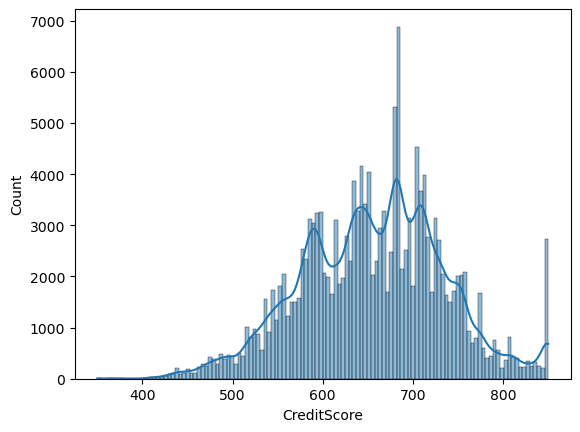

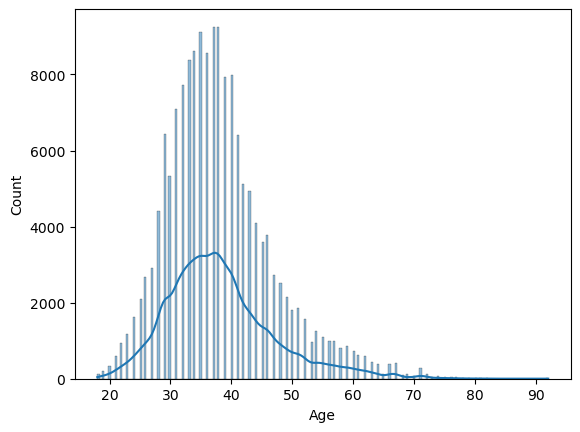

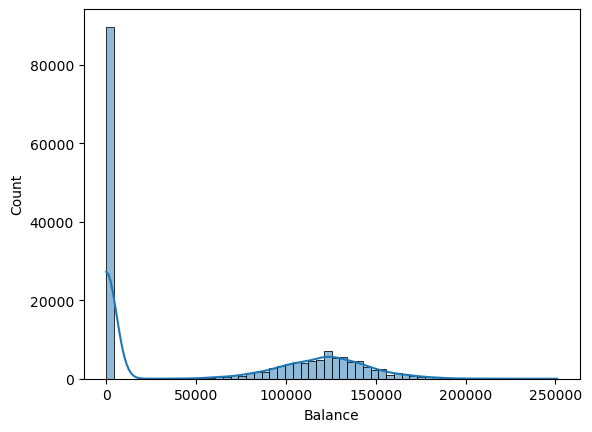

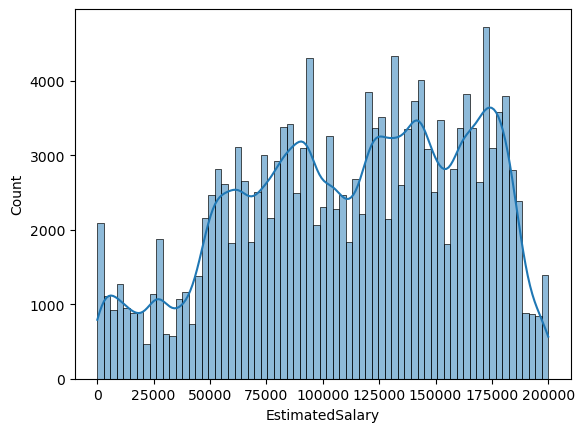

In [11]:
for cols in num_columns:
    sns.histplot(df_train[cols], kde = True)
    plt.show()

In [12]:
df_train.columns

Index(['id', 'CustomerId', 'Surname', 'CreditScore', 'Geography', 'Gender',
       'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard',
       'IsActiveMember', 'EstimatedSalary', 'Exited'],
      dtype='object')

#### Categorical Columns

##### Geography, Gender, Tenure, NumOfProducts, HasCrCard, IsActiveMember, Exited 

In [13]:
cat_columns = ['Geography', 'Gender', 'Tenure', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'Exited']

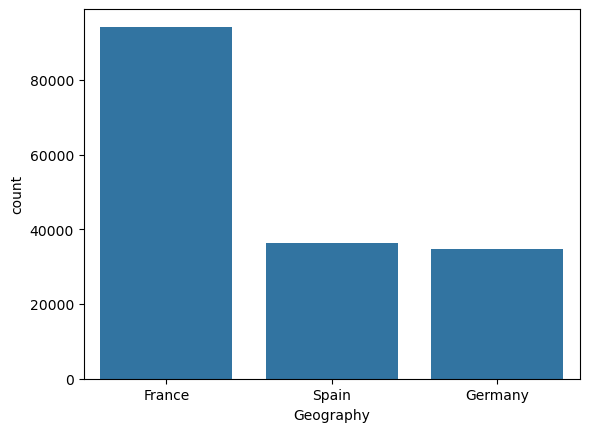

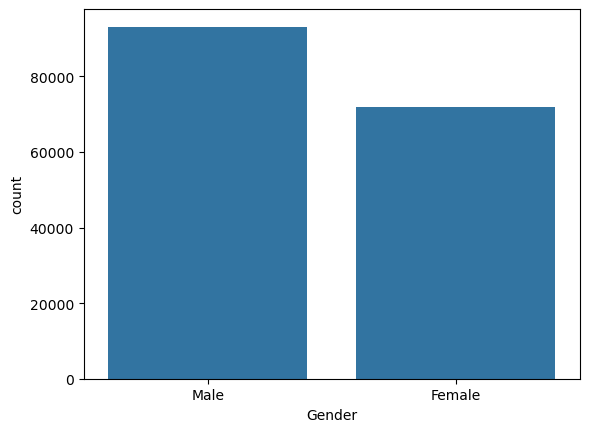

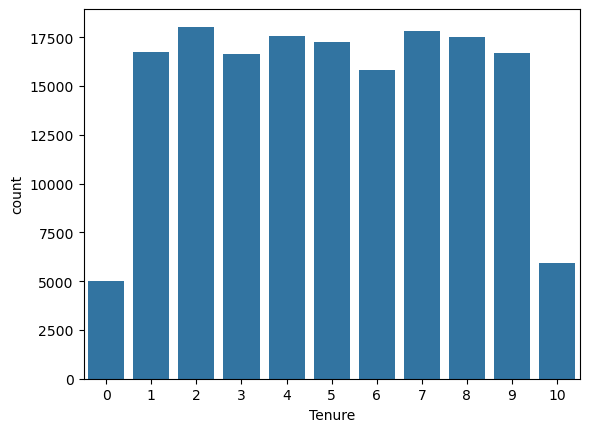

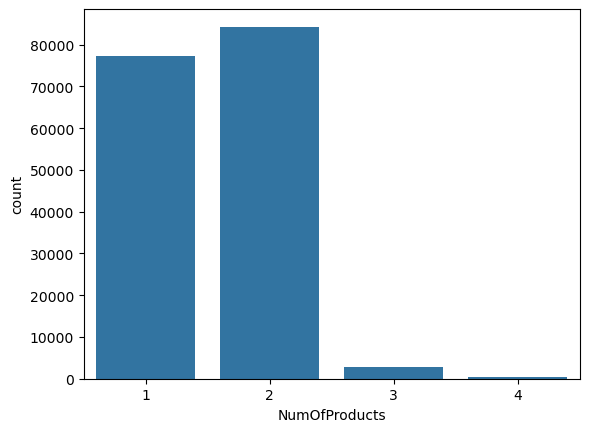

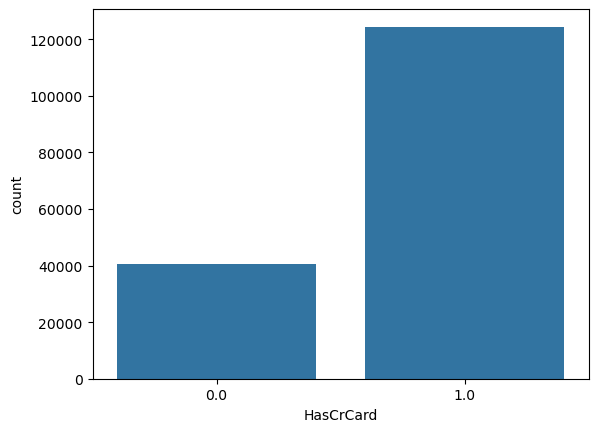

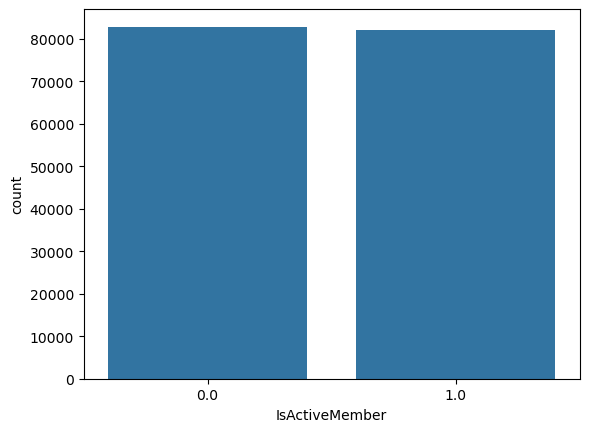

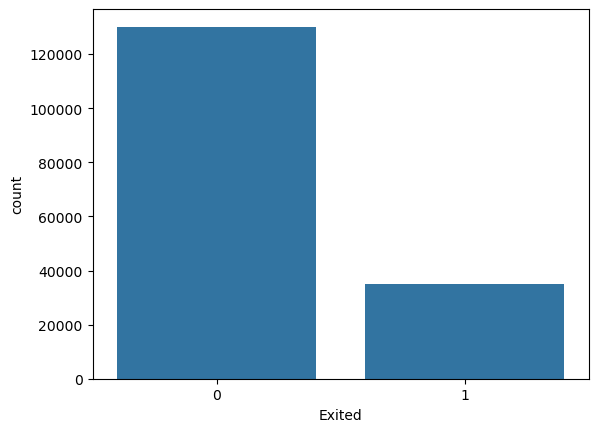

In [14]:
for col in cat_columns:
    sns.countplot(df_train, x=df_train[col])
    plt.show()

In [15]:
df_train['Tenure'].value_counts()

Tenure
2     18045
7     17810
4     17554
8     17520
5     17268
1     16760
9     16709
3     16630
6     15822
10     5909
0      5007
Name: count, dtype: int64

In [16]:
df_train['Geography'].value_counts()

Geography
France     94215
Spain      36213
Germany    34606
Name: count, dtype: int64

In [17]:
df_train['Gender'].value_counts()

Gender
Male      93150
Female    71884
Name: count, dtype: int64

In [18]:
df_train['NumOfProducts'].value_counts()

NumOfProducts
2    84291
1    77374
3     2894
4      475
Name: count, dtype: int64

In [19]:
df_train['HasCrCard'].value_counts()

HasCrCard
1.0    124428
0.0     40606
Name: count, dtype: int64

In [20]:
df_train['IsActiveMember'].value_counts()

IsActiveMember
0.0    82885
1.0    82149
Name: count, dtype: int64

In [21]:
df_train['Exited'].value_counts()

Exited
0    130113
1     34921
Name: count, dtype: int64

In [22]:
from sklearn.preprocessing import LabelEncoder

leG = LabelEncoder()
df_train['Gender'] = leG.fit_transform(df_train['Gender'])

leGE = LabelEncoder()
df_train['Geography'] = leGE.fit_transform(df_train['Geography'])

In [23]:
df_train.drop(columns=['Surname', 'CustomerId', 'id'], inplace =True)

In [24]:
df_train

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,668,0,1,33.0,3,0.00,2,1.0,0.0,181449.97,0
1,627,0,1,33.0,1,0.00,2,1.0,1.0,49503.50,0
2,678,0,1,40.0,10,0.00,2,1.0,0.0,184866.69,0
3,581,0,1,34.0,2,148882.54,1,1.0,1.0,84560.88,0
4,716,2,1,33.0,5,0.00,2,1.0,1.0,15068.83,0
...,...,...,...,...,...,...,...,...,...,...,...
165029,667,2,0,33.0,2,0.00,1,1.0,1.0,131834.75,0
165030,792,0,1,35.0,3,0.00,1,0.0,0.0,131834.45,0
165031,565,0,1,31.0,5,0.00,1,1.0,1.0,127429.56,0
165032,554,2,0,30.0,7,161533.00,1,0.0,1.0,71173.03,0


In [25]:
df_test

,id,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary
0,165034,15773898,Lucchese,586,France,Female,23.0,2,0.00,2,0.0,1.0,160976.75
1,165035,15782418,Nott,683,France,Female,46.0,2,0.00,1,1.0,0.0,72549.27
2,165036,15807120,K?,656,France,Female,34.0,7,0.00,2,1.0,0.0,138882.09
3,165037,15808905,O'Donnell,681,France,Male,36.0,8,0.00,1,1.0,0.0,113931.57
4,165038,15607314,Higgins,752,Germany,Male,38.0,10,121263.62,1,1.0,0.0,139431.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...
110018,275052,15662091,P'eng,570,Spain,Male,29.0,7,116099.82,1,1.0,1.0,148087.62
110019,275053,15774133,Cox,575,France,Female,36.0,4,178032.53,1,1.0,1.0,42181.68
110020,275054,15728456,Ch'iu,712,France,Male,31.0,2,0.00,2,1.0,0.0,16287.38
110021,275055,15687541,Yegorova,709,France,Female,32.0,3,0.00,1,1.0,1.0,158816.58


In [26]:
leG = LabelEncoder()
df_test['Gender'] = leG.fit_transform(df_test['Gender'])

leGE = LabelEncoder()
df_test['Geography'] = leGE.fit_transform(df_test['Geography'])

In [27]:
df_test.drop(columns=['Surname', 'CustomerId', 'id'], inplace =True)

In [28]:
df_test

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary
0,586,0,0,23.0,2,0.00,2,0.0,1.0,160976.75
1,683,0,0,46.0,2,0.00,1,1.0,0.0,72549.27
2,656,0,0,34.0,7,0.00,2,1.0,0.0,138882.09
3,681,0,1,36.0,8,0.00,1,1.0,0.0,113931.57
4,752,1,1,38.0,10,121263.62,1,1.0,0.0,139431.00
...,...,...,...,...,...,...,...,...,...,...
110018,570,2,1,29.0,7,116099.82,1,1.0,1.0,148087.62
110019,575,0,0,36.0,4,178032.53,1,1.0,1.0,42181.68
110020,712,0,1,31.0,2,0.00,2,1.0,0.0,16287.38
110021,709,0,0,32.0,3,0.00,1,1.0,1.0,158816.58


## Model Building

In [29]:
from sklearn.model_selection import train_test_split
X = df_train.drop('Exited', axis=1)
y = df_train['Exited']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

In [30]:
model = tf.keras.models.Sequential([
    tf.keras.layers.Dense(128, activation='relu', input_shape=(X_train.shape[1],)), # Input Layer
    tf.keras.layers.Dense(64, activation='relu'), # Hidden layer 1
    tf.keras.layers.Dense(32, activation='relu'), # Hidden layer 2
    tf.keras.layers.Dense(16, activation='relu'), # Hidden layer 3
    tf.keras.layers.Dense(8, activation='relu'),  # Hidden layer 4
    tf.keras.layers.Dense(4, activation='relu'),  # Hidden layer 5
    
    tf.keras.layers.Dense(1, activation='sigmoid') # Output layer 

])

c:\Users\ZhuanZ\miniconda3\envs\ai_env\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [31]:
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

history = model.fit(X_train, y_train, epochs=30, batch_size=32, verbose=1, validation_data=[X_test, y_test])
loss, accuracy = model.evaluate(X_test, y_test, verbose=0)

Epoch 1/30
4126/4126 ━━━━━━━━━━━━━━━━━━━━ 14s 3ms/step - accuracy: 0.7860 - loss: 0.6866 - val_accuracy: 0.7893 - val_loss: 0.5149
Epoch 2/30
4126/4126 ━━━━━━━━━━━━━━━━━━━━ 12s 3ms/step - accuracy: 0.7882 - loss: 0.5164 - val_accuracy: 0.7893 - val_loss: 0.5149
Epoch 3/30
4126/4126 ━━━━━━━━━━━━━━━━━━━━ 12s 3ms/step - accuracy: 0.7882 - loss: 0.5164 - val_accuracy: 0.7893 - val_loss: 0.5149
Epoch 4/30
4126/4126 ━━━━━━━━━━━━━━━━━━━━ 12s 3ms/step - accuracy: 0.7882 - loss: 0.5164 - val_accuracy: 0.7893 - val_loss: 0.5149
Epoch 5/30
4126/4126 ━━━━━━━━━━━━━━━━━━━━ 12s 3ms/step - accuracy: 0.7882 - loss: 0.5164 - val_accuracy: 0.7893 - val_loss: 0.5149
Epoch 6/30
4126/4126 ━━━━━━━━━━━━━━━━━━━━ 11s 3ms/step - accuracy: 0.7882 - loss: 0.5164 - val_accuracy: 0.7893 - val_loss: 0.5149
Epoch 7/30
4126/4126 ━━━━━━━━━━━━━━━━━━━━ 12s 3ms/step - accuracy: 0.7882 - loss: 0.5164 - val_accuracy: 0.7893 - val_loss: 0.5150
Epoch 8/30
4126/4126 ━━━━━━━━━━━━━━━━━━━━ 12s 3ms/step - accuracy: 0.7882 - loss: 0

In [33]:
print('Accuracy:', accuracy)
print('Loss', loss)

Accuracy: 0.7892871499061584
Loss 0.5149017572402954


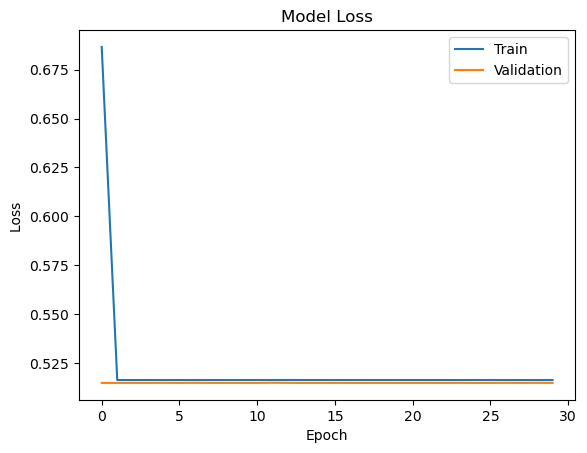

In [32]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.ylabel('Loss ')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper right')
plt.show()


## Training XGBoost Classifer

In [36]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# train the XGBoost model
xgb = XGBClassifier()
xgb.fit(X_train, y_train)

# Predict the Test Data
y_pred = xgb.predict(X_test)

print("Accuracy Score:", accuracy_score(y_test, y_pred))
print("Precision Score:", precision_score(y_test, y_pred))
print("Recall Score:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))

Accuracy Score: 0.8669676129305904
Precision Score: 0.7403449568803899
Recall Score: 0.5677929547088426
F1 Score: 0.6426885832858654


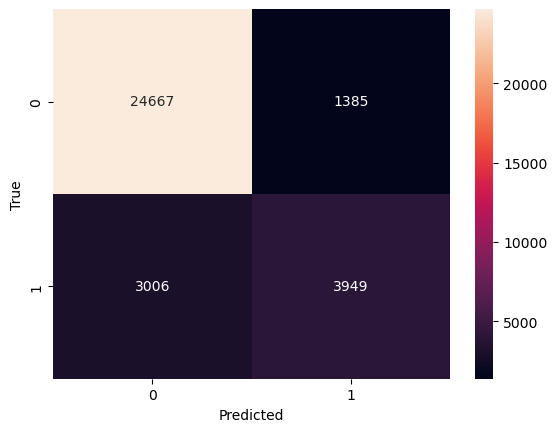

In [38]:
# Plot Confusion Matrix
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel('True')
plt.show()